<a href="https://colab.research.google.com/github/Gay2004/data_science/blob/main/GroupProject_1questionAidaiSharabidinova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# ================================
# 1. Import libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: improve plot aesthetics
sns.set(style="whitegrid")


# ================================
# 2. Load dataset
# ================================
# Replace with your actual file path
df = pd.read_excel("Spring2021_Anon_comments_done!.xlsx")

# Rename columns as per user's clarification
rename_map = {
    "Question 2": "Q2",
    "Question 3": "Q3",
    "Question 4": "Q4",
    "Question 5": "Q5",
    "Question 6": "Q6",
    "Question 7": "Q7"
}
# Filter rename_map to only include columns present in df to avoid potential errors
existing_columns = df.columns.tolist()
filtered_rename_map = {old_name: new_name for old_name, new_name in rename_map.items() if old_name in existing_columns}
df.rename(columns=filtered_rename_map, inplace=True)


# ================================
# 3. Data preparation
# ================================

# Keep only relevant columns
cols = ["Q2", "Q3", "Q4", "Q5", "Q6", "Q7"]
df = df[cols]

# Drop rows with missing values in key questions and create a proper copy to avoid SettingWithCopyWarning
df_clean = df.dropna(subset=["Q4", "Q5", "Q6", "Q7"]).copy()


# ================================
# 4. Descriptive statistics
# ================================

# Mean and standard deviation
desc_stats = df_clean[["Q4", "Q5", "Q6", "Q7"]].agg(["mean", "std"])
print("\nDescriptive statistics:\n", desc_stats)


# ================================
# 5. Distribution (percentages)
# ================================

def get_distribution(series):
    return series.value_counts(normalize=True).sort_index() * 100

dist_Q4 = get_distribution(df_clean["Q4"])
dist_Q5 = get_distribution(df_clean["Q5"])
dist_Q6 = get_distribution(df_clean["Q6"])
dist_Q7 = get_distribution(df_clean["Q7"])

print("\nDistribution Q4:\n", dist_Q4)
print("\nDistribution Q5:\n", dist_Q5)
print("\nDistribution Q6:\n", dist_Q6)
print("\nDistribution Q7:\n", dist_Q7)


# ================================
# 6. Group by year of study (Q2)
# ================================

year_means = df_clean.groupby("Q2")[["Q4", "Q5", "Q6", "Q7"]].mean()
print("\nMeans by Year of Study:\n", year_means)


# ================================
# 7. Group by course type (Q3)
# ================================

course_means = df_clean.groupby("Q3")[["Q4", "Q5", "Q6", "Q7"]].mean()
print("\nMeans by Course Type:\n", course_means)


# ================================
# 11. Optional: Save results
# ================================

year_means.to_csv("year_means.csv")
course_means.to_csv("course_means.csv")
desc_stats.to_csv("descriptive_stats.csv")


Descriptive statistics:
             Q4        Q5        Q6        Q7
mean  4.687469  4.540786  4.466585  4.291646
std   0.634949  0.747689  0.782104  0.907197

Distribution Q4:
 Q4
1.0     0.638821
2.0     0.810811
3.0     3.144963
4.0    19.975430
5.0    75.429975
Name: proportion, dtype: float64

Distribution Q5:
 Q5
1.0     0.835381
2.0     1.179361
3.0     6.977887
4.0    25.085995
5.0    65.921376
Name: proportion, dtype: float64

Distribution Q6:
 Q6
1.0     1.007371
2.0     1.498771
3.0     7.592138
4.0    29.631450
5.0    60.270270
Name: proportion, dtype: float64

Distribution Q7:
 Q7
1.0     1.375921
2.0     2.825553
3.0    14.078624
4.0    28.697789
5.0    53.022113
Name: proportion, dtype: float64

Means by Year of Study:
            Q4        Q5        Q6        Q7
Q2                                         
1.0  4.776119  4.731343  4.671642  4.567164
2.0  4.706989  4.604839  4.502688  4.225806
3.0  4.683938  4.545769  4.421416  4.264249
4.0  4.579407  4.366492  4.350785

In [27]:
# ================================
# 9. Plotting helper function
# ================================

def plot_distribution(series, title):
    dist = get_distribution(series)
    plt.figure()
    dist.plot(kind="bar")
    plt.title(title)
    plt.xlabel("Response")
    plt.ylabel("Percentage")
    plt.tight_layout()
    plt.show()

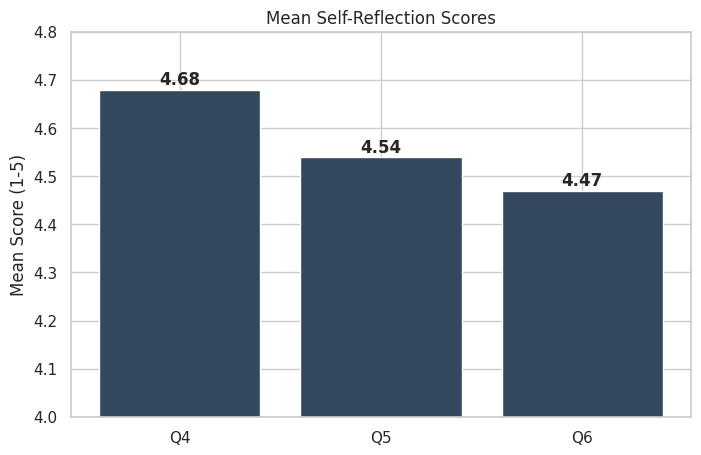

In [38]:
# MINIMAL TEST — no fancy axis break, just clean bars
plt.figure(figsize=(8,5))
plt.bar(['Q4', 'Q5', 'Q6'], [4.68, 4.54, 4.47], color='#34495e')
plt.ylim(4.0, 4.8)
plt.ylabel('Mean Score (1-5)')
plt.title('Mean Self-Reflection Scores')
# Add values on bars
for i, v in enumerate([4.68, 4.54, 4.47]):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')
plt.show()

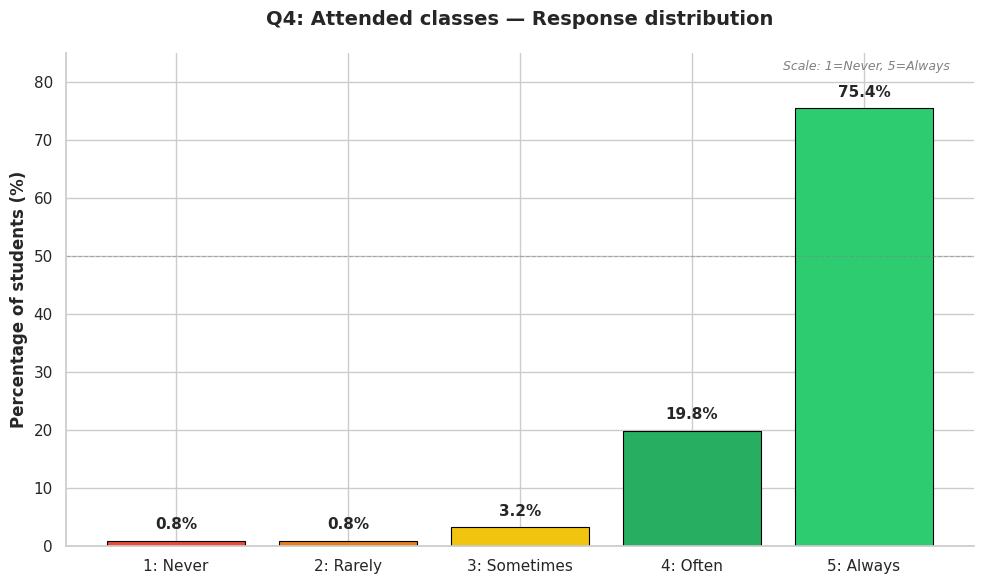

In [29]:
# ================================
# Q4 DISTRIBUTION CHART (Attendance)
# ================================

import matplotlib.pyplot as plt
import numpy as np

# Data
response_labels = ['1: Never', '2: Rarely', '3: Sometimes', '4: Often', '5: Always']
percentages = [0.8, 0.8, 3.2, 19.8, 75.4]
n = 4277

# Colors: gradient from light red to dark green
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#27ae60', '#2ecc71']

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars
bars = ax.bar(response_labels, percentages, color=colors, edgecolor='black', linewidth=0.8)

# ===== Y-AXIS =====
ax.set_ylim(0, 85)  # Slightly above max (75.4)
ax.set_ylabel('Percentage of students (%)', fontsize=12, fontweight='bold')

# ===== TITLE =====
ax.set_title('Q4: Attended classes — Response distribution', fontsize=14, fontweight='bold', pad=20)

# ===== VALUE LABELS ON BARS =====
for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{pct}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# ===== ADD REFERENCE LINE FOR 50% =====
ax.axhline(y=50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# ===== REMOVE TOP SPINE =====
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ===== ADD NOTE ABOUT SCALE =====
ax.text(4.5, 82, 'Scale: 1=Never, 5=Always',
        fontsize=9, style='italic', color='gray', ha='right')

plt.tight_layout()
plt.savefig('Q4_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

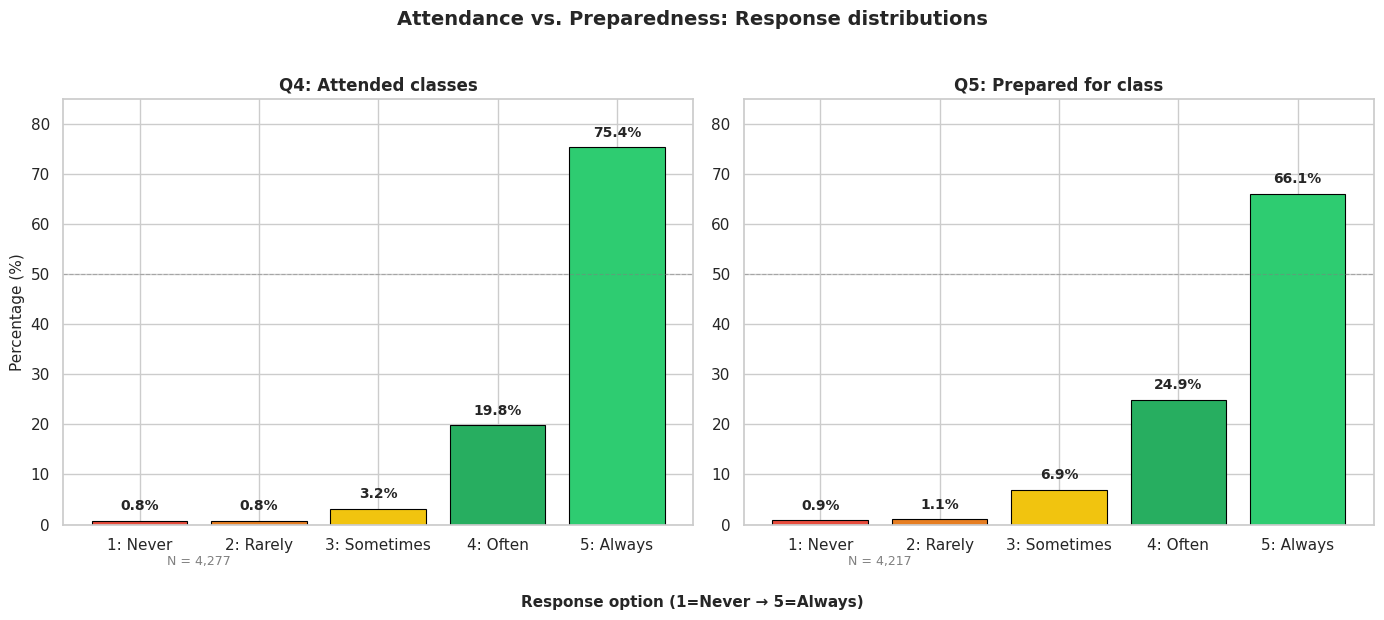

In [30]:
# ================================
# Q4 AND Q5 SIDE BY SIDE
# ================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Q4 data
labels_q4 = ['1: Never', '2: Rarely', '3: Sometimes', '4: Often', '5: Always']
pct_q4 = [0.8, 0.8, 3.2, 19.8, 75.4]
colors_q4 = ['#e74c3c', '#e67e22', '#f1c40f', '#27ae60', '#2ecc71']

bars1 = ax1.bar(labels_q4, pct_q4, color=colors_q4, edgecolor='black', linewidth=0.8)
ax1.set_ylim(0, 85)
ax1.set_ylabel('Percentage (%)', fontsize=11)
ax1.set_title('Q4: Attended classes', fontsize=12, fontweight='bold')
ax1.axhline(y=50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

for bar, pct in zip(bars1, pct_q4):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{pct}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Q5 data
pct_q5 = [0.9, 1.1, 6.9, 24.9, 66.1]

bars2 = ax2.bar(labels_q4, pct_q5, color=colors_q4, edgecolor='black', linewidth=0.8)
ax2.set_ylim(0, 85)
ax2.set_title('Q5: Prepared for class', fontsize=12, fontweight='bold')
ax2.axhline(y=50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

for bar, pct in zip(bars2, pct_q5):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{pct}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Common x-axis label
fig.supxlabel('Response option (1=Never → 5=Always)', fontsize=11, fontweight='bold', y=0.02)

# Add sample sizes
ax1.text(0.5, -8, 'N = 4,277', fontsize=9, color='gray', ha='center', transform=ax1.transData)
ax2.text(0.5, -8, 'N = 4,217', fontsize=9, color='gray', ha='center', transform=ax2.transData)

plt.suptitle('Attendance vs. Preparedness: Response distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Q4_Q5_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

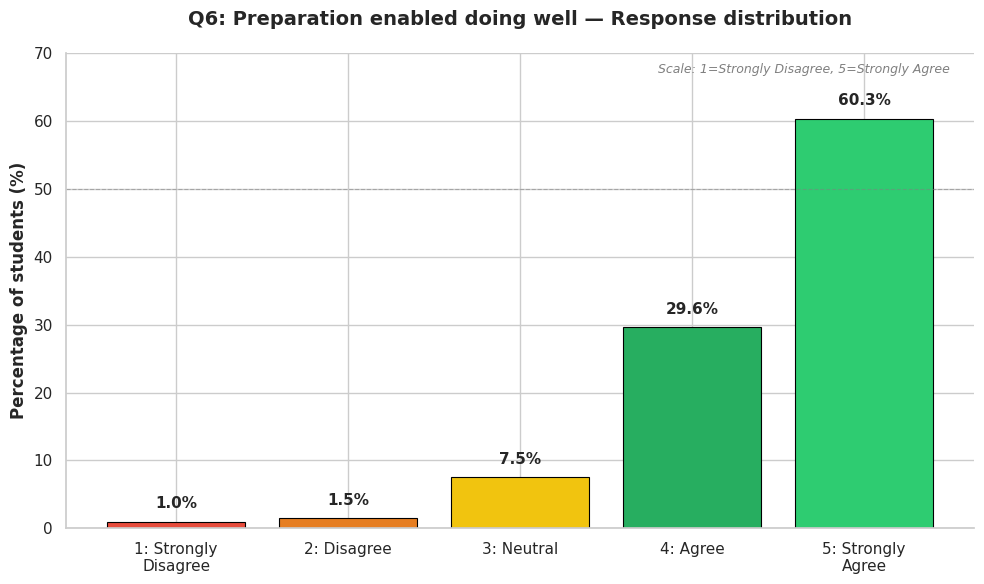

In [31]:
# ================================
# Q6 DISTRIBUTION CHART (Preparation → Success)
# ================================

import matplotlib.pyplot as plt
import numpy as np

# Data — NOTE: Different scale from Q4/Q5!
response_labels = ['1: Strongly\nDisagree', '2: Disagree', '3: Neutral', '4: Agree', '5: Strongly\nAgree']
percentages = [1.0, 1.5, 7.5, 29.6, 60.3]
n = 4212

# Colors: gradient from light red to dark green (consistent with previous)
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#27ae60', '#2ecc71']

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars
bars = ax.bar(response_labels, percentages, color=colors, edgecolor='black', linewidth=0.8)

# ===== Y-AXIS =====
ax.set_ylim(0, 70)  # Slightly above max (60.3)
ax.set_ylabel('Percentage of students (%)', fontsize=12, fontweight='bold')
# ===== TITLE =====
ax.set_title('Q6: Preparation enabled doing well — Response distribution', fontsize=14, fontweight='bold', pad=20)

# ===== VALUE LABELS ON BARS =====
for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{pct}%', ha='center', va='bottom', fontsize=11, fontweight='bold')


# ===== ADD REFERENCE LINE FOR 50% =====
ax.axhline(y=50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# ===== REMOVE TOP AND RIGHT SPINES =====
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ===== ADD NOTE ABOUT SCALE =====
ax.text(4.5, 67, 'Scale: 1=Strongly Disagree, 5=Strongly Agree',
        fontsize=9, style='italic', color='gray', ha='right')

plt.tight_layout()
plt.savefig('Q6_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

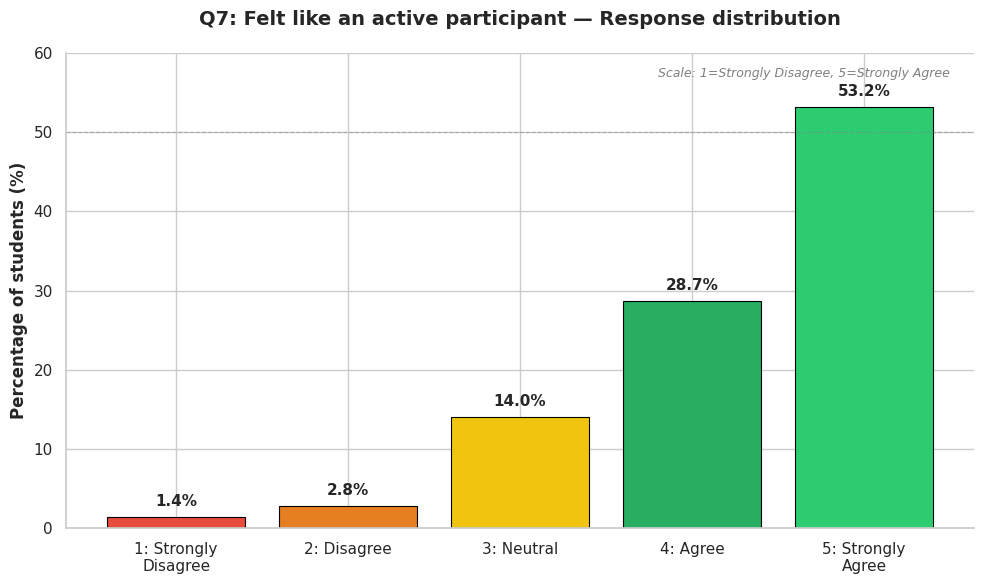

In [32]:
# ================================
# Q7 DISTRIBUTION CHART (Active Participation)
# ================================

import matplotlib.pyplot as plt

# Data — from your HTML file
response_labels = ['1: Strongly\nDisagree', '2: Disagree', '3: Neutral', '4: Agree', '5: Strongly\nAgree']
percentages = [1.4, 2.8, 14.0, 28.7, 53.2]
n = 4195

# Colors: red → orange → yellow → green → dark green
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#27ae60', '#2ecc71']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(response_labels, percentages, color=colors, edgecolor='black', linewidth=0.8)

# Y-axis
ax.set_ylim(0, 60)
ax.set_ylabel('Percentage of students (%)', fontsize=12, fontweight='bold')

# Title
ax.set_title('Q7: Felt like an active participant — Response distribution', fontsize=14, fontweight='bold', pad=20)

# Value labels on bars
for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.0,
            f'{pct}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Reference line at 50%
ax.axhline(y=50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Clean up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Scale note
ax.text(4.5, 57, 'Scale: 1=Strongly Disagree, 5=Strongly Agree',
        fontsize=9, style='italic', color='gray', ha='right')

plt.tight_layout()
plt.savefig('Q7_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

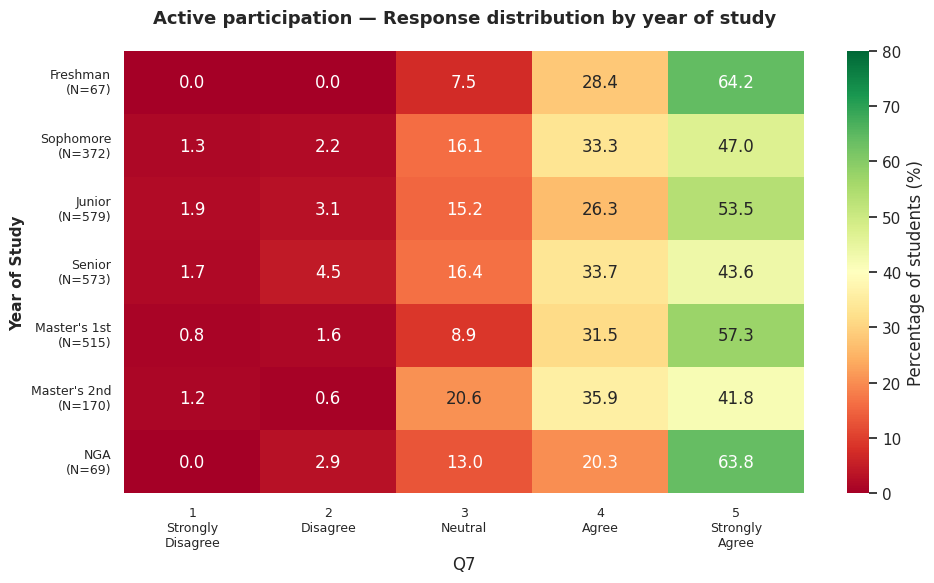

In [47]:
# ================================
# HEATMAP: Q7 by Year of Study (IMPROVED)
# ================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define logical order for years (adjust based on your actual categories)
year_order = ['Freshman', 'Sophomore', 'Junior', 'Senior', "Master's 1st", "Master's 2nd", 'NGA']

# Create a mapping from numerical Q2 values to string labels
q2_numerical_to_label = {
    1.0: 'Freshman',
    2.0: 'Sophomore',
    3.0: 'Junior',
    4.0: 'Senior',
    5.0: "Master's 1st",
    6.0: "Master's 2nd",
    7.0: 'NGA'
}

# Fix for SettingWithCopyWarning: create an explicit copy for operations
# This ensures modifications are made on a standalone DataFrame and avoids the warning.
df_clean_for_heatmap = df_clean.copy()
df_clean_for_heatmap.loc[:, 'Q2_Label'] = df_clean_for_heatmap['Q2'].map(q2_numerical_to_label)

# Create distribution table with proper order, using the new 'Q2_Label' column
heatmap_data = (
    df_clean_for_heatmap
    .groupby("Q2_Label")["Q7"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)  # Fill missing response options with 0
    * 100
)

# Reindex to your desired order to ensure all years are present and in order,
# filling with 0 for categories that might not have appeared in the data.
heatmap_data = heatmap_data.reindex(year_order, fill_value=0)

# Add sample size to row labels
n_per_year = df_clean_for_heatmap.groupby("Q2_Label")["Q7"].count()
# Ensure n_per_year also has the same order and handles missing categories
n_per_year = n_per_year.reindex(year_order, fill_value=0)
row_labels = [f"{year}\n(N={n_per_year[year]})" for year in year_order]

# Create figure with appropriate size
fig, ax = plt.subplots(figsize=(10, 6))

# Create heatmap with diverging colormap (red = low agreement, green = high agreement)
# RdYlGn: Red = bad/low, Yellow = neutral, Green = good/high
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    vmin=0,
    vmax=80,  # Adjust based on your max percentage
    cbar_kws={'label': 'Percentage of students (%)'},
    ax=ax
)

# Fix row labels with N
ax.set_yticklabels(row_labels, rotation=0, fontsize=9)

# Fix column labels (response options)
ax.set_xticklabels(['1\nStrongly\nDisagree', '2\nDisagree', '3\nNeutral', '4\nAgree', '5\nStrongly\nAgree'],
                   fontsize=9)

# Labels and title
ax.set_ylabel("Year of Study", fontsize=11, fontweight='bold')
ax.set_title("Active participation — Response distribution by year of study",
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('heatmap_Q7_by_year.png', dpi=300, bbox_inches='tight')
plt.show()
